In [ ]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../')
sys.path.append('../')
from src import plot_utils as pu

os.makedirs("rebuttal_figs", exist_ok=True)

base_dir = "/network/projects/linclab_users/eg/modcog/pingsheng_rebuttal/"

/tmp/ipykernel_3576183/2384266188.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'rebuttal_figs/1c_response_acc_no_unsigned_eg.pdf'

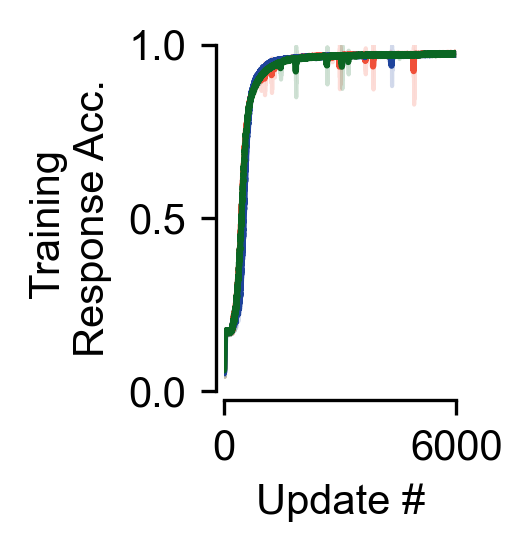

In [2]:
# fig 1: training curves
data_path = base_dir + "plot_data/fig1c_response_acc_data.npz"
data = np.load(data_path, allow_pickle=True)

colors = ["#f05039", "#1f449c", "#0b6623", "#ff33ff"]

xlims = (0, 6000)
ylims = (0, 1)

plt.figure(figsize=(1.,1.5), dpi = 300)

for i, key in enumerate(data):
    if i == 3:  break # plot only EG without sign correction
    mean = data[key].item()['mean']
    std = data[key].item()['std']
    plt.plot(mean, label=key, color=colors[i])
    plt.fill_between(range(len(mean)), 
                     mean - std, 
                     mean + std, alpha=0.2, color=colors[i])
                
ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx: plt.xscale("log")
if logy: plt.yscale("log")

y_step = 0.5
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Training \nResponse Acc.", rotation=90)

#sns.despine()
sns.despine(offset=2, trim=True)

# plt.legend(frameon=False, fontsize=8, loc='best')

plt.tight_layout()
plt.savefig("rebuttal_figs/1c_response_acc_no_unsigned_eg.pdf", transparent=True, bbox_inches='tight', dpi=200)
plt.savefig("rebuttal_figs/1c_response_acc_no_unsigned_eg.svg", transparent=True, bbox_inches='tight', dpi=200)
plt.show()

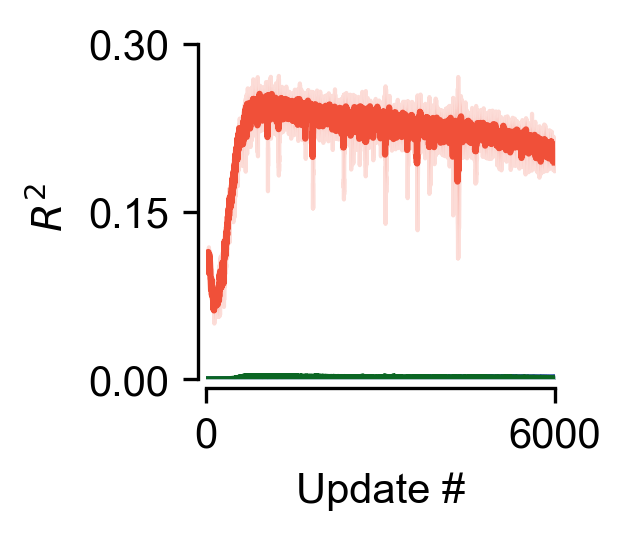

In [ ]:
plt.figure(figsize=(1.5,1.5), dpi = 300)

data_path = base_dir + "plot_data/fig1g_r2_data.npz"
data = np.load(data_path, allow_pickle=True)

for i, key in enumerate(data):
    mean = data[key].item()['mean']
    std = data[key].item()['std']
    plt.plot(mean, label=key, color=colors[i])
    plt.fill_between(range(len(mean)), 
                     mean - std, 
                     mean + std, alpha=0.2, color=colors[i])

plt.ylabel(r'$R^2$')
plt.xlabel('Update #')  

ax = plt.gca()
xlims = (0, 6000)
ylims = (0, 0.31)
y_step = 0.15
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

sns.despine(offset=2, trim=True)
plt.savefig("rebuttal_figs/1g_r2.pdf", bbox_inches="tight")
plt.savefig("rebuttal_figs/1g_r2.svg", bbox_inches="tight", dpi=200)
plt.show()

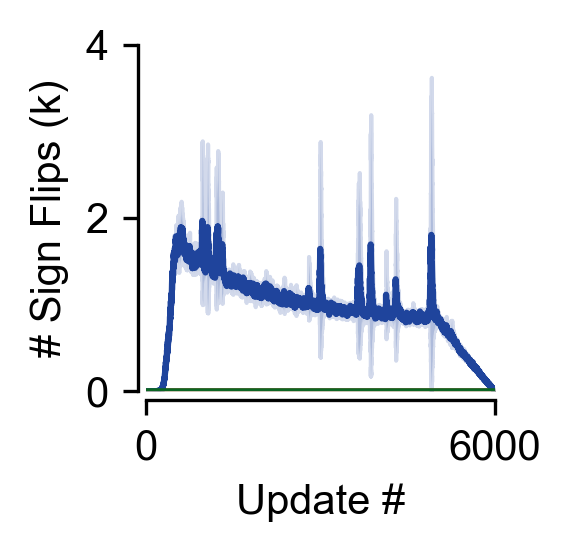

In [ ]:
plt.figure(figsize=(1.5,1.5), dpi = 300)

data_path = base_dir + "plot_data/fig1f_sign_flips_data.npz"
data = np.load(data_path, allow_pickle=True)
for i, key in enumerate(data):
    mean = data[key].item()['mean']
    std = data[key].item()['std']
    plt.plot(mean, label=key, color=colors[i])
    plt.fill_between(range(len(mean)), 
                     mean - std, 
                     mean + std, alpha=0.2, color=colors[i])

plt.ylabel('# Sign Flips (k)')
plt.xlabel('Update #')  

ax = plt.gca()
xlims = (0, 6000)
ylims = (0, 4000)
y_step = 2000
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
yticks = np.arange(ylims[0],ylims[1]+y_step, y_step)
ylabels = [int(int(s)/1000) for s in yticks]
ax.set_yticks(yticks, labels=ylabels) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

sns.despine(offset=2, trim=True)
plt.savefig("rebuttal_figs/1f_sign_flips.pdf", bbox_inches="tight")
plt.savefig("rebuttal_figs/1f_sign_flips.svg", bbox_inches="tight", dpi=200)
plt.show()

x_lims are (-10.01, 2.0)


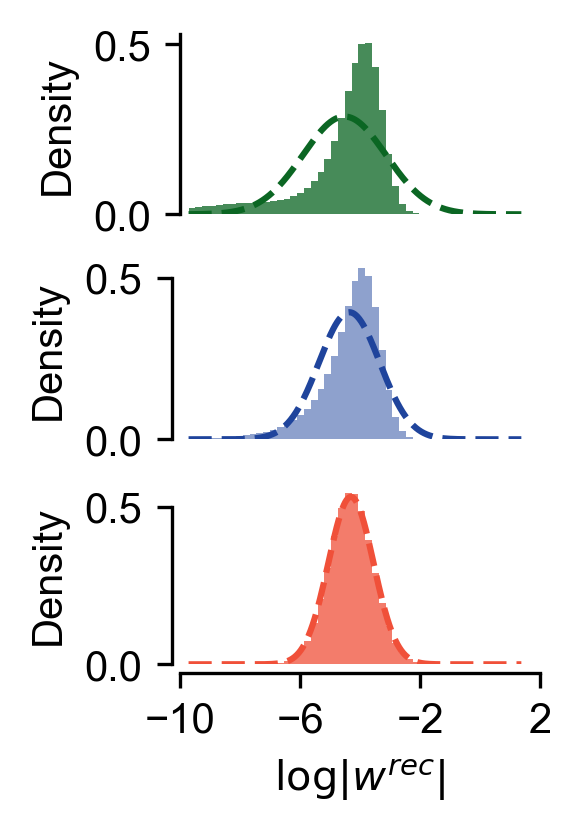

6249227 6238909 6040836


In [ ]:
from scipy.stats import norm

figsize_tuple = (1.5,1.5)
seperate_plots = True
gaussian_approx = True
xlims_step=(-10, 2, 4)
ylims_step=None
kde = False
stat = 'density'  # 'count' 'density'
log_y_scale = False
axis_off = False

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)

fig = plt.figure(figsize=figsize_tuple, dpi = 300)

if seperate_plots:
    # Add an axes to the figure at position [left, bottom, width, height]
    # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
    # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
    ax_eg = fig.add_axes([0.0, 0., 0.8, .4])
    ax_gd = fig.add_axes([0.0, 0.5, 0.8, .4])
    ax_cgd = fig.add_axes([0.0, 1.0, 0.8, .4])
else:
    ax_eg = fig.add_subplot(111)
    ax_gd = ax_eg

data_path = base_dir + "plot_data/fig1e_ln_weights_hists_data.npz"
_, eg_exp_results = list(np.load(data_path, allow_pickle=True).items())[0]
_, gd_exp_results = list(np.load(data_path, allow_pickle=True).items())[1]

data_path = base_dir + "plot_data/1e_ln_weights_hists_data.pkl"
with open(data_path, "rb") as f:
    cgd_exp_results = pickle.load(f)

eg_arr = eg_exp_results.item()['weights']
gd_arr = gd_exp_results.item()['weights']
cgd_arr = cgd_exp_results[0]

max_weight = np.max([np.max(eg_arr), np.max(gd_arr), np.max(cgd_arr)])
bin_edges = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr), np.min(cgd_arr)])), max_weight, 50)

sns.histplot(eg_arr, bins = bin_edges, kde=kde, stat=stat, color=colors[0], ec=None,
            label='EG', ax=ax_eg)

if gaussian_approx:
    points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
    ax_eg.plot(points, get_norm_pdf(points, eg_arr.mean(), eg_arr.std()), color=colors[0],
            linestyle='--')

sns.histplot(gd_arr, bins = bin_edges, kde=kde, stat=stat, color=colors[1], ec=None, alpha=0.5,
            label='GD', ax=ax_gd)

if gaussian_approx:
    points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
    ax_gd.plot(points, get_norm_pdf(points, gd_arr.mean(), gd_arr.std()), color=colors[1],
            linestyle='--')

sns.histplot(cgd_arr, bins = bin_edges, kde=kde, stat=stat, color=colors[2], ec=None, alpha=0.5,
            label='cGD', ax=ax_cgd)

if gaussian_approx:
    sns.histplot(cgd_arr, bins = bin_edges, kde=kde, stat=stat, color=colors[2], ec=None, alpha=0.5,
            label='cGD', ax=ax_cgd)
    points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr), np.min(cgd_arr)])), max_weight, 500)
    ax_cgd.plot(points, get_norm_pdf(points, cgd_arr.mean(), cgd_arr.std()), color=colors[2],
            linestyle='--')
    
if ylims_step is not None:
    ticks = np.arange(ylims_step[0],ylims_step[1]+ylims_step[2], ylims_step[2])
    ax_eg.set_yticks(ticks)
    ax_eg.set_ylim(ylims_step[0],ylims_step[1])

    ax_gd.set_yticks(ticks)
    ax_gd.set_ylim(ylims_step[0],ylims_step[1])

    ax_cgd.set_yticks(ticks)
    ax_cgd.set_ylim(ylims_step[0],ylims_step[1])
    

if xlims_step is not None:
    ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])
    ax_eg.set_xticks(ticks)
    ax_eg.set_xlim(xlims_step[0],xlims_step[1])

    ax_gd.set_xticks(ticks)
    ax_gd.set_xlim(xlims_step[0],xlims_step[1])

    ax_cgd.set_xticks(ticks)
    ax_cgd.set_xlim(xlims_step[0],xlims_step[1])

# Manually set the same x-limits for both subplots
x_limits = (min(ax_eg.get_xlim()[0], ax_gd.get_xlim()[0], ax_cgd.get_xlim()[0])-0.01, max(ax_eg.get_xlim()[1], ax_gd.get_xlim()[1], ax_cgd.get_xlim()[1]))
ax_eg.set_xlim(x_limits)
ax_gd.set_xlim(x_limits)
ax_cgd.set_xlim(x_limits)
print(f"x_lims are {x_limits}")

sns.despine(offset=2, trim=True, ax=ax_eg)
sns.despine(offset=2, trim=True, ax=ax_gd) 
if seperate_plots:
    #ax_gd.spines['left'].set_visible(False)
    ax_gd.spines['bottom'].set_visible(False)
    ax_gd.xaxis.set_visible(False)
    ax_cgd.spines['bottom'].set_visible(False)
    ax_cgd.spines['top'].set_visible(False)
    ax_cgd.spines['right'].set_visible(False)
    ax_cgd.xaxis.set_visible(False)
    
# ax_gd.set_xlabel(r"$\log |w^{rec}|$")
ax_eg.set_xlabel(r"$\log |w^{rec}|$")

if log_y_scale: plt.yscale("log")
#if stat != 'count': plt.legend(loc='upper left')
if axis_off: 
    ax_gd.axis("off")
    ax_eg.axis("off")
    ax_cgd.axis("off")
plt.savefig("rebuttal_figs/1e_ln_weights_hists.pdf", transparent=True, bbox_inches='tight')
plt.savefig("rebuttal_figs/1e_ln_weights_hists.svg", transparent=True, bbox_inches='tight', dpi=200)
plt.show()
print(len(eg_arr), len(gd_arr), len(cgd_arr))

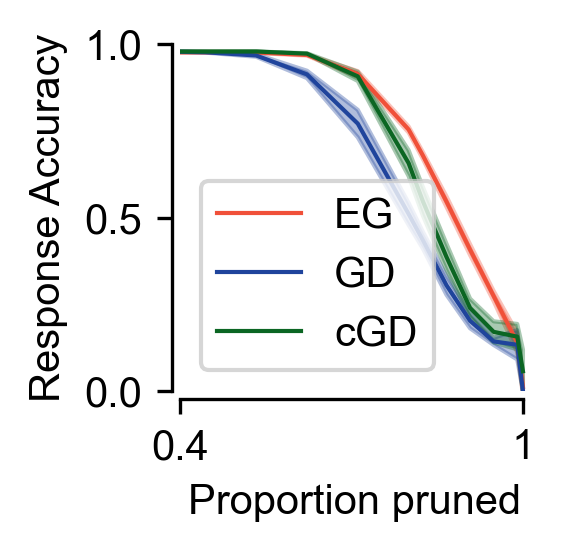

In [10]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
gd_c="#1f449c"
eg_c="#f05039"
cgd_c="#0b6623"

data = np.load(base_dir + "plot_data/Fig2a_cSGD_dec_acc.npz", allow_pickle=True)
prune_props = data["prune_props"]
eg_arr = data["eg_dec_acc"]
gd_arr = data["gd_dec_acc"]
cgd_arr = data["cgd_dec_acc"]

plt.fill_between(prune_props, 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.35)

plt.plot(prune_props, eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1, label="EG")

plt.fill_between(prune_props, 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.35)

plt.plot(prune_props, gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1, label="GD")

plt.fill_between(prune_props, 
                 cgd_arr.mean(axis=1)-cgd_arr.std(axis=1), cgd_arr.mean(axis=1)+cgd_arr.std(axis=1),
                 color=cgd_c, alpha=0.35)       

plt.plot(prune_props, cgd_arr.mean(axis=1), color=cgd_c, alpha=1, lw=1, label="cGD")


plt.legend(frameon=False)
plt.ylim(0., 1)
plt.yticks([0, 0.5, 1])
plt.xlim(0.4,1.01)
plt.xticks([0.4, 1], labels=["0.4", "1"])

plt.xlabel("Proportion pruned")
plt.ylabel("Response Accuracy")
plt.legend()

sns.despine(offset=2, trim=True)
plt.savefig("rebuttal_figs/2c_dec_acc.pdf", transparent=True, bbox_inches='tight')
plt.savefig("rebuttal_figs/2c_dec_acc.svg", transparent=True, bbox_inches='tight', dpi=200)
plt.show()

/tmp/ipykernel_3576183/2300748073.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


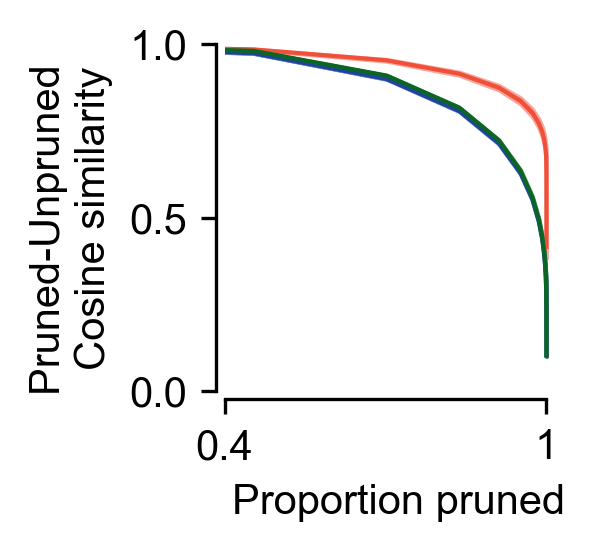

In [5]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
gd_c="#1f449c" # "#f05039", "#1f449c", "#0b6623"
eg_c="#f05039"
cgd_c="#0b6623"

data = np.load(base_dir + "plot_data/Fig2a_cSGD_cos_sims_ln.npz", allow_pickle=True)
prune_props = data["prune_props"]
eg_arr = data["eg_cos_sims_ln"]
gd_arr = data["gd_cos_sims_ln"]
cgd_arr = data["cgd_cos_sims_ln"]

# plt.plot(prune_props, gd_cos_sims_ln,  color=gd_c)
# plt.plot(prune_props, eg_cos_sims_ln,  color=eg_c)

plt.fill_between(prune_props, 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.5)

plt.plot(prune_props, eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.5)

plt.plot(prune_props, gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 cgd_arr.mean(axis=1)-cgd_arr.std(axis=1), cgd_arr.mean(axis=1)+cgd_arr.std(axis=1),
                 color=cgd_c, alpha=0.5)    

plt.plot(prune_props, cgd_arr.mean(axis=1), color=cgd_c, alpha=1, lw=1)

plt.legend(frameon=False)
plt.ylim(0., 1)
plt.yticks([0, 0.5, 1])
plt.xlim(0.4,1.05)
#plt.xticks([0.4, max(prune_props)], labels=["0.4", str(max(prune_props))])
plt.xticks([0.4, 1], labels=["0.4", "1"])


plt.ylabel("Pruned-Unpruned  \nCosine similarity")
plt.xlabel("Proportion pruned")
#plt.title("EG vs GD with reference dists")
sns.despine(offset=2, trim=True)

plt.savefig("rebuttal_figs/2b_cos_sim_ln.pdf", transparent=True, bbox_inches='tight')
plt.savefig("rebuttal_figs/2b_cos_sim_ln.svg", transparent=True, bbox_inches='tight',dpi=200)
plt.show()



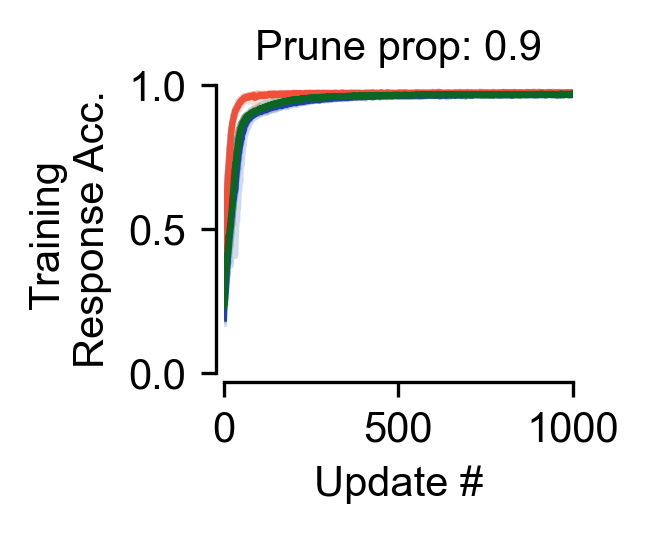

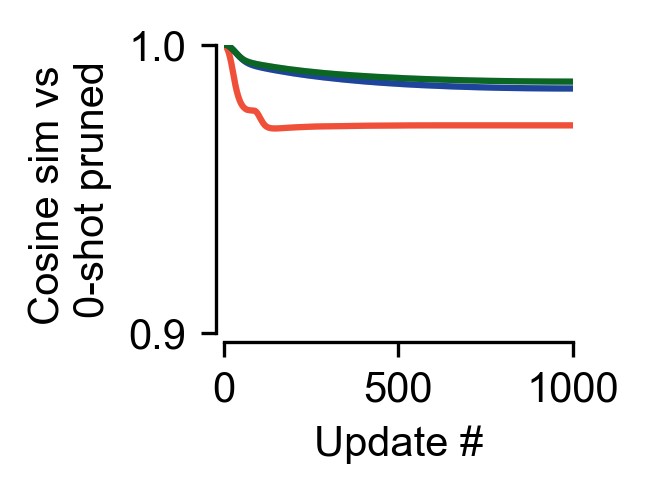

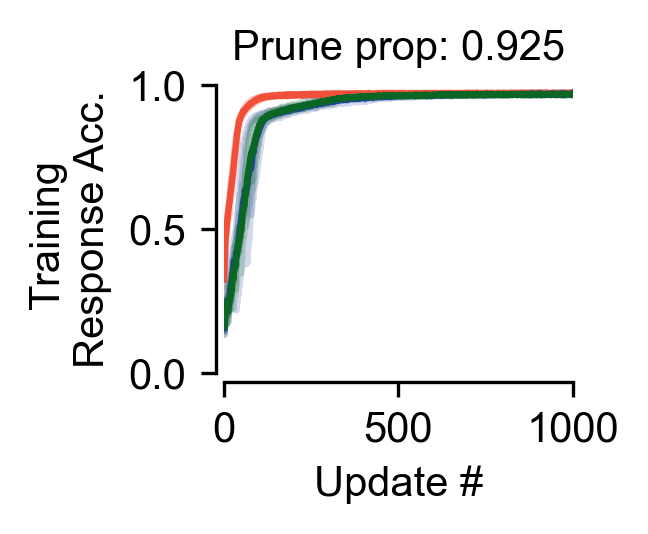

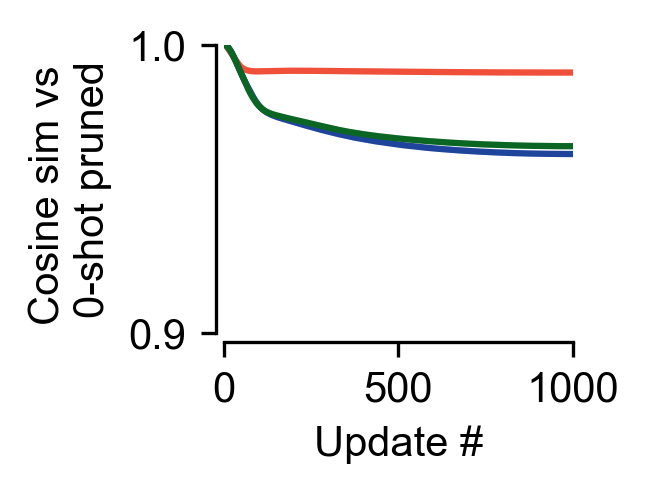

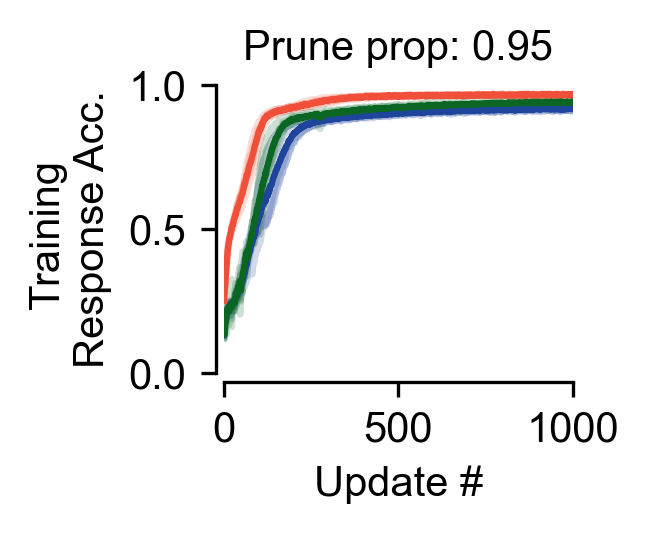

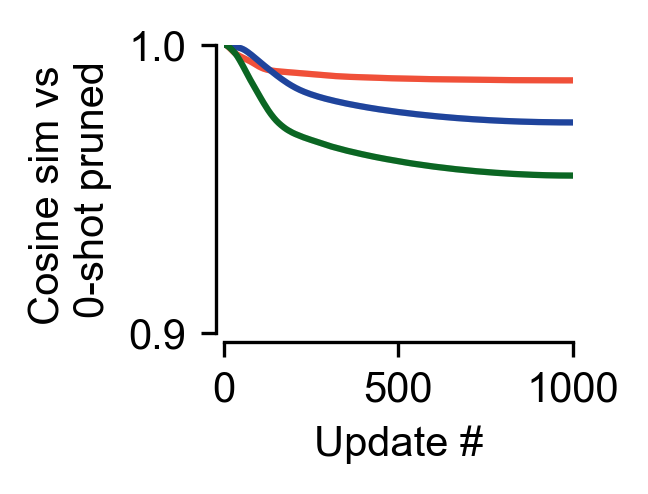

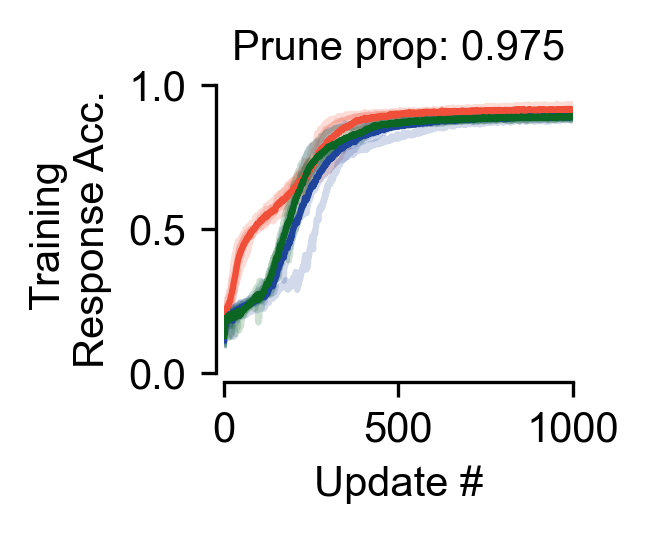

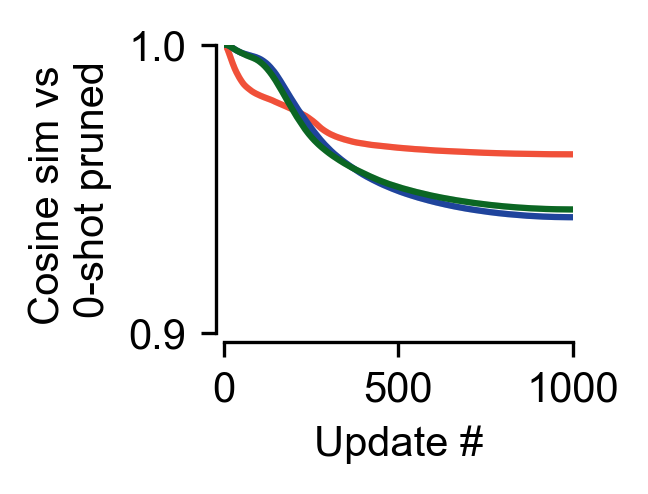

In [ ]:
pps = [0.9, 0.925, 0.95, 0.975]
gd_c="#1f449c"
eg_c="#f05039"
cgd_c="#0b6623"
for pp in pps:

    data = pickle.load(open(base_dir + f"plot_data/Fig2b_cSGD_response_acc_data_{pp}.pkl", "rb"))
    eg_data = data['eg']
    gd_data = data['gd']
    cgd_data = data['cgd']

    eg_data_nonmean = data['eg_nonmean']
    gd_data_nonmean = data['gd_nonmean']
    cgd_data_nonmean = data['cgd_nonmean']

    line_alpha=0.2
    
    fig1_size = (1.5,1.25)
    fig1 = plt.figure(figsize=fig1_size, dpi = 300)
    
    plt.plot(eg_data_nonmean, c=eg_c, alpha=0.2)
    plt.plot(gd_data_nonmean, c=gd_c, alpha=0.2)
    plt.plot(cgd_data_nonmean, c=cgd_c, alpha=0.2)
    plt.plot(eg_data_nonmean.mean(axis=1), c=eg_c, alpha=1)
    plt.plot(gd_data_nonmean.mean(axis=1), c=gd_c, alpha=1)
    plt.plot(cgd_data_nonmean.mean(axis=1), c=cgd_c, alpha=1)
    plt.xlabel("Update #")
    plt.ylabel("Training \nResponse Acc.", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.,1)
    plt.yticks([0,0.5,1])
    sns.despine(offset=2)
    plt.title(f"Prune prop: {pp}", fontsize=10)
    plt.savefig(f"rebuttal_figs/2b_cSGD_response_acc_prune_prop_{pp}.pdf", transparent=True, bbox_inches='tight')
    plt.savefig(f"rebuttal_figs/2b_cSGD_response_acc_prune_prop_{pp}.svg", transparent=True, bbox_inches='tight', dpi=200)
    plt.show()

    data = pickle.load(open(base_dir + f"plot_data/Fig2b_cSGD_cos_sim_data_{pp}.pkl", "rb"))
    eg_data = data['eg']
    gd_data = data['gd']
    cgd_data = data['cgd']

    eg_data_nonmean = data['eg_nonmean']
    gd_data_nonmean = data['gd_nonmean']
    cgd_data_nonmean = data['cgd_nonmean']
    
    
    fig2_size = (1.5,1.25)
    fig2 = plt.figure(figsize=fig2_size, dpi = 300)
    
    plt.plot(eg_data, c=eg_c, alpha=0.2)
    plt.plot(gd_data, c=gd_c, alpha=0.2)
    plt.plot(cgd_data, c=cgd_c, alpha=0.2)
    plt.plot(eg_data_nonmean.mean(axis=1), c=eg_c, alpha=1)
    plt.plot(gd_data_nonmean.mean(axis=1), c=gd_c, alpha=1)
    plt.plot(cgd_data_nonmean.mean(axis=1), c=cgd_c, alpha=1)
    sns.despine(offset=2)
    plt.xlabel("Update #")
    plt.ylabel("Cosine sim vs \n0-shot pruned", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.9,1)
    plt.yticks([0.9,1])
    plt.savefig(f"rebuttal_figs/2b_cSGD_cos_sim_prune_prop_{pp}.pdf", transparent=True, bbox_inches='tight')
    plt.savefig(f"rebuttal_figs/2b_cSGD_cos_sim_prune_prop_{pp}.svg", transparent=True, bbox_inches='tight', dpi=200)
    plt.show()
  